In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()

In [ ]:
print(torch.cuda.memory_allocated() / 1024**3)
print(torch.cuda.memory_reserved() / 1024**3)

0.0
0.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

thesis_path = "/content/drive/MyDrive/Thesis"

print(os.listdir(thesis_path))

['uppdms.v2-v1_baseline_70_15_15.yolov8.zip', 'uppdms_baseline1', 'Experiments1', 'RTDETRl_Baseline.zip']


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Thesis/uppdms.v2-v1_baseline_70_15_15.yolov8.zip"

extract_path = "/content/drive/MyDrive/Thesis/uppdms_baseline1"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

KeyboardInterrupt: 

In [ ]:
print(os.listdir(extract_path))

['valid', 'train', 'test', 'data.yaml', 'README.roboflow.txt', 'README.dataset.txt']


In [ ]:
for split in ["train", "valid", "test"]:
    image_dir = os.path.join(extract_path, split, "images")
    label_dir = os.path.join(extract_path, split, "labels")

    print(f"\n{split.upper()}")
    print("Images:", len(os.listdir(image_dir)))
    print("Labels:", len(os.listdir(label_dir)))


TRAIN
Images: 1338
Labels: 1338

VALID
Images: 287
Labels: 287

TEST
Images: 287
Labels: 287


In [ ]:
yaml_path = os.path.join(extract_path, "data.yaml")

with open(yaml_path, "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 8
names: ['bottle_cap', 'glove', 'mask', 'net', 'plastic_bag', 'plastic_bottle', 'plastic_cup', 'plastic_straw']

roboflow:
  workspace: sanzida-tazin-arafa-s-workspace
  project: uppdms
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/sanzida-tazin-arafa-s-workspace/uppdms/dataset/2


In [ ]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 6.0 MB/s eta 0:00:00


In [ ]:
import ultralytics
print("Ultralytics version:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.120


In [ ]:
import sys
import torch
import ultralytics

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("Ultralytics:", ultralytics.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA: 12.8
Ultralytics: 8.4.120
GPU: Tesla T4


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/Thesis/uppdms_baseline1"

EXPERIMENT_PATH = "/content/drive/MyDrive/Thesis/Experiments1"

os.makedirs(EXPERIMENT_PATH, exist_ok=True)

YAML_PATH = os.path.join(DATASET_PATH, "data.yaml")

print("Dataset:", DATASET_PATH)
print("YAML:", YAML_PATH)
print("Experiments:", EXPERIMENT_PATH)

Dataset: /content/drive/MyDrive/Thesis/uppdms_baseline1
YAML: /content/drive/MyDrive/Thesis/uppdms_baseline1/data.yaml
Experiments: /content/drive/MyDrive/Thesis/Experiments1


In [ ]:
for split in ["train", "valid", "test"]:
    image_dir = os.path.join(DATASET_PATH, split, "images")
    label_dir = os.path.join(DATASET_PATH, split, "labels")

    print(f"\n{split.upper()}")
    print("Images:", len(os.listdir(image_dir)))
    print("Labels:", len(os.listdir(label_dir)))


TRAIN
Images: 1338
Labels: 1338

VALID
Images: 287
Labels: 287

TEST
Images: 287
Labels: 287


In [ ]:
with open(YAML_PATH, "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 8
names: ['bottle_cap', 'glove', 'mask', 'net', 'plastic_bag', 'plastic_bottle', 'plastic_cup', 'plastic_straw']

roboflow:
  workspace: sanzida-tazin-arafa-s-workspace
  project: uppdms
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/sanzida-tazin-arafa-s-workspace/uppdms/dataset/2


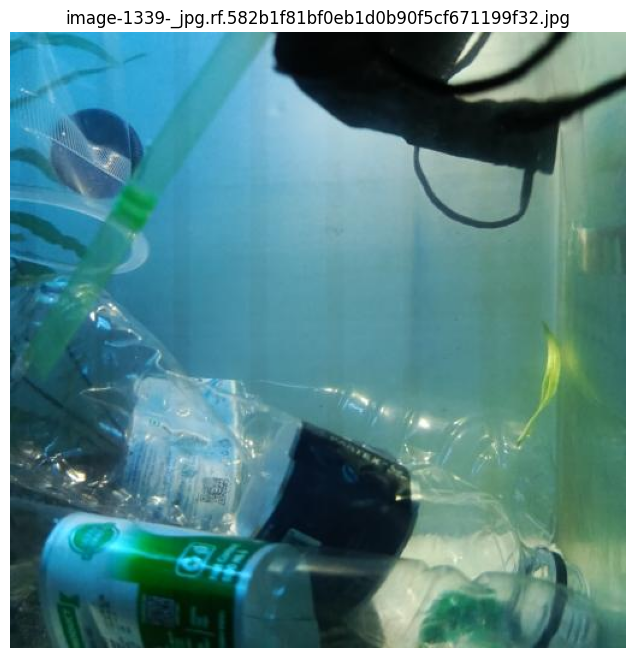

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import random
import os

image_dir = os.path.join(DATASET_PATH, "train", "images")

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

sample = random.choice(image_files)

img = Image.open(os.path.join(image_dir, sample))

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title(sample)
plt.show()

YOLOv8 Baseline Training

In [ ]:
from ultralytics import YOLO

yolov8 = YOLO("yolov8n.pt")

In [ ]:
yolov8_results = yolov8.train(
    data=YAML_PATH,
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=20,
    optimizer="AdamW",
    pretrained=True,
    plots=True,
    save=True,
    project=EXPERIMENT_PATH,
    name="YOLOv8n_Baseline"
)

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Thesis/uppdms_baseline1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOL

In [ ]:
print("YOLOv8 training finished.")

YOLOv8 training finished.


In [ ]:
best_model_path_yolov8 = f"{EXPERIMENT_PATH}/YOLOv8n_Baseline/weights/best.pt"

print("Best model:", best_model_path_yolov8)
print("Exists:", os.path.exists(best_model_path_yolov8))

Best model: /content/drive/MyDrive/Thesis/Experiments1/YOLOv8n_Baseline/weights/best.pt
Exists: True


In [ ]:
best_model_path_yolov8 = "/content/drive/MyDrive/Thesis/Experiments1/YOLOv8n_Baseline/weights/best.pt"

yolov8_best = YOLO(best_model_path_yolov8)


test_results_yolov8 = yolov8_best.val(
    data=YAML_PATH,
    split="test",
    imgsz=640,
    batch=16,
    device=0
)


print("\nYOLOv8n TEST RESULTS")
print("====================")
print("Precision :", test_results_yolov8.box.mp)
print("Recall    :", test_results_yolov8.box.mr)
print("mAP50     :", test_results_yolov8.box.map50)
print("mAP50-95  :", test_results_yolov8.box.map)

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.8±0.4 ms, read: 14.5±4.1 MB/s, size: 27.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Thesis/uppdms_baseline1/test/labels.cache... 287 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 287/287 75.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 3.3it/s 5.4s
                   all        287       1278      0.758      0.746      0.792      0.538
            bottle_cap        114        183      0.873      0.863      0.909      0.701
                 glove         78         87        0.8       0.78      0.865      0.543
                  mask        130        188 

In [ ]:
# Test the original YOLOv8n baseline on the same test set, for fair comparison
from ultralytics import YOLO

baseline_model = YOLO("/content/drive/MyDrive/Thesis/Experiments1/YOLOv8n_Baseline/weights/best.pt")

baseline_test_results = baseline_model.val(
    data="/content/drive/MyDrive/Thesis/uppdms_baseline1/data.yaml",
    split="test",
    project="/content/drive/MyDrive/Thesis/Experiments1",
    name="YOLOv8n_Baseline_test_results",
)

print("Baseline Test mAP50:", baseline_test_results.box.map50)
print("Baseline Test mAP50-95:", baseline_test_results.box.map)
print("Baseline Test Precision:", baseline_test_results.box.mp)
print("Baseline Test Recall:", baseline_test_results.box.mr)

In [ ]:
P_yolov8 = test_results_yolov8.box.mp
R_yolov8 = test_results_yolov8.box.mr

F1_yolov8 = 2 * (P_yolov8 * R_yolov8) / (P_yolov8 + R_yolov8)

print("YOLOv8n F1-score:", F1_yolov8)

YOLOv8n F1-score: 0.738473029265156


YOLOv11 Baseline Training

In [ ]:
from ultralytics import YOLO

model_yolo11 = YOLO("yolo11n.pt")

In [ ]:
results_yolo11 = model_yolo11.train(
    data=YAML_PATH,
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=20,
    optimizer="AdamW",
    pretrained=True,
    plots=True,
    save=True,
    project=EXPERIMENT_PATH,
    name="YOLO11n_Baseline"
)

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Thesis/uppdms_baseline1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOL

In [ ]:
print("YOLOv11 training finished.")

YOLOv11 training finished.


In [ ]:
best_model_path_yolo11 = (f"{EXPERIMENT_PATH}/YOLO11n_Baseline/weights/best.pt")

print("YOLO11 best model path:")
print(best_model_path_yolo11)

print("Exists:", os.path.exists(best_model_path_yolo11))

YOLO11 best model path:
/content/drive/MyDrive/Thesis/Experiments1/YOLO11n_Baseline/weights/best.pt
Exists: True


In [ ]:
best_model_path_yolo11 = "/content/drive/MyDrive/Thesis/Experiments1/YOLO11n_Baseline/weights/best.pt"

model_yolo11_best = YOLO(best_model_path_yolo11)


test_results_yolo11 = model_yolo11_best.val(
    data=YAML_PATH,
    split="test",
    imgsz=640,
    batch=16,
    device=0
)


print("\nYOLO11n TEST RESULTS")
print("====================")
print("Precision :", test_results_yolo11.box.mp)
print("Recall    :", test_results_yolo11.box.mr)
print("mAP50     :", test_results_yolo11.box.map50)
print("mAP50-95  :", test_results_yolo11.box.map)

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,712 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.8±0.4 ms, read: 11.4±4.8 MB/s, size: 21.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Thesis/uppdms_baseline1/test/labels... 287 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 287/287 128.4it/s 2.2s
val: New cache created: /content/drive/MyDrive/Thesis/uppdms_baseline1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 2.4it/s 7.4s
                   all        287       1278      0.857      0.795      0.858      0.638
            bottle_cap        114        183      0.951      0.869      0.922      0.737
                 glove         78         87    

In [ ]:
P_yolo11 = test_results_yolo11.box.mp
R_yolo11 = test_results_yolo11.box.mr

F1_yolo11 = 2 * (P_yolo11 * R_yolo11) / (P_yolo11 + R_yolo11)

print("YOLO11n F1-score:", F1_yolo11)

YOLO11n F1-score: 0.8247739198074542


Split Test

In [ ]:
print("YAML_PATH:", YAML_PATH)

with open(YAML_PATH, "r") as f:
    print(f.read())

YAML_PATH: /content/drive/MyDrive/Thesis/uppdms_baseline1/data.yaml
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 8
names: ['bottle_cap', 'glove', 'mask', 'net', 'plastic_bag', 'plastic_bottle', 'plastic_cup', 'plastic_straw']

roboflow:
  workspace: sanzida-tazin-arafa-s-workspace
  project: uppdms
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/sanzida-tazin-arafa-s-workspace/uppdms/dataset/2


In [ ]:
for split in ["train", "valid", "test"]:
    image_dir = os.path.join(DATASET_PATH, split, "images")

    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(split, "images:", len(images))

train images: 1338
valid images: 287
test images: 287


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Thesis/uppdms_baseline1"
YAML_PATH = os.path.join(DATASET_PATH, "data.yaml")

for split in ["train", "valid", "test"]:
    image_dir = os.path.join(DATASET_PATH, split, "images")
    label_dir = os.path.join(DATASET_PATH, split, "labels")

    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    labels = [
        f for f in os.listdir(label_dir)
        if f.lower().endswith(".txt")
    ]

    print(f"\n{split.upper()}")
    print("Images:", len(images))
    print("Labels:", len(labels))


TRAIN
Images: 1338
Labels: 1338

VALID
Images: 287
Labels: 287

TEST
Images: 287
Labels: 287


In [ ]:
print("Dataset:", DATASET_PATH)
print("YAML:", YAML_PATH)
print("Experiments:", EXPERIMENT_PATH)

Dataset: /content/drive/MyDrive/Thesis/uppdms_baseline1
YAML: /content/drive/MyDrive/Thesis/uppdms_baseline1/data.yaml
Experiments: /content/drive/MyDrive/Thesis/Experiments1


In [ ]:
print("Current YAML:")
print(YAML_PATH)

with open(YAML_PATH, "r") as f:
    print(f.read())

print("\nCurrent test directory:")
print(os.path.abspath(os.path.join(DATASET_PATH, "test", "images")))

print(
    "Test image count:",
    len([
        f for f in os.listdir(os.path.join(DATASET_PATH, "test", "images"))
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
)

Current YAML:
/content/drive/MyDrive/Thesis/uppdms_baseline1/data.yaml
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 8
names: ['bottle_cap', 'glove', 'mask', 'net', 'plastic_bag', 'plastic_bottle', 'plastic_cup', 'plastic_straw']

roboflow:
  workspace: sanzida-tazin-arafa-s-workspace
  project: uppdms
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/sanzida-tazin-arafa-s-workspace/uppdms/dataset/2

Current test directory:
/content/drive/MyDrive/Thesis/uppdms_baseline1/test/images
Test image count: 287


RT-DETR_L Baseline Training

YOLO26 Baseline Training

In [ ]:
import os
from ultralytics import YOLO

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")
print(model.model.yaml)

{'nc': 80, 'end2end': True, 'reg_max': 1, 'scales': {'n': [0.5, 0.25, 1024], 's': [0.5, 0.5, 1024], 'm': [0.5, 1.0, 512], 'l': [1.0, 1.0, 512], 'x': [1.0, 1.5, 512]}, 'backbone': [[-1, 1, 'Conv', [64, 3, 2]], [-1, 1, 'Conv', [128, 3, 2]], [-1, 2, 'C3k2', [256, False, 0.25]], [-1, 1, 'Conv', [256, 3, 2]], [-1, 2, 'C3k2', [512, False, 0.25]], [-1, 1, 'Conv', [512, 3, 2]], [-1, 2, 'C3k2', [512, True]], [-1, 1, 'Conv', [1024, 3, 2]], [-1, 2, 'C3k2', [1024, True]], [-1, 1, 'SPPF', [1024, 5, 3, True]], [-1, 2, 'C2PSA', [1024]]], 'head': [[-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 6], 1, 'Concat', [1]], [-1, 2, 'C3k2', [512, True]], [-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 4], 1, 'Concat', [1]], [-1, 2, 'C3k2', [256, True]], [-1, 1, 'Conv', [256, 3, 2]], [[-1, 13], 1, 'Concat', [1]], [-1, 2, 'C3k2', [512, True]], [-1, 1, 'Conv', [512, 3, 2]], [[-1, 10], 1, 'Concat', [1]], [-1, 1, 'C3k2', [1024, True, 0.5, True]], [[16, 19, 22], 1, 'Detect', ['nc']]], 'scale': 'n', 'yam

In [ ]:
from ultralytics import __version__
print(__version__)

from ultralytics import YOLO

model = YOLO("yolo26n.pt")

8.4.115


In [ ]:
results = model.train(
    data=YAML_PATH,

    epochs=100,
    imgsz=640,
    batch=16,

    device=0,

    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,

    project=EXPERIMENT_PATH,
    name="YOLO26-Baseline",

    pretrained=True,

    seed=42,
    patience=20,
    verbose=True
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Thesis/uppdms_baseline1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YO

In [ ]:
best_model_path_yolo26 = f"{EXPERIMENT_PATH}/YOLO26-Baseline/weights/best.pt"

print("Best model:", best_model_path_yolo26)
print("Exists:", os.path.exists(best_model_path_yolo26))

Best model: /content/drive/MyDrive/Thesis/Experiments1/YOLO26-Baseline/weights/best.pt
Exists: True


In [ ]:
from ultralytics import YOLO

yolo26_best = YOLO(best_model_path_yolo26)

test_results_yolo26 = yolo26_best.val(
    data=YAML_PATH,
    split="test",
    imgsz=640,
    batch=16,
    device=0
)

print("\nYOLO26 TEST RESULTS")
print("===================")
print("Precision :", test_results_yolo26.box.mp)
print("Recall    :", test_results_yolo26.box.mr)
print("mAP50     :", test_results_yolo26.box.map50)
print("mAP50-95  :", test_results_yolo26.box.map)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,396 parameters, 0 gradients, 5.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.7±0.3 ms, read: 11.8±4.3 MB/s, size: 24.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Thesis/uppdms_baseline1/test/labels.cache... 287 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 287/287 86.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 3.2it/s 5.7s
                   all        287       1278      0.901      0.826      0.891      0.695
            bottle_cap        114        183      0.915      0.902      0.926      0.755
                 glove         78         87      0.956      0.897      0.963       0.78
                  mask        130        1

In [ ]:
# Unzip RTDETRl_Baseline
import zipfile
import os

zip_path = "/content/drive/MyDrive/Thesis/RTDETRl_Baseline.zip"

extract_path = "/content/drive/MyDrive/Thesis/Experiments1"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
print(os.listdir("/content/drive/MyDrive/Thesis/Experiments1"))

['YOLOv8n_Baseline', 'YOLO11n_Baseline', 'YOLO26-Baseline', 'RTDETRl_Baseline']


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/Thesis/Experiments1/RTDETRl_Baseline"):
    print(root)
    for f in files:
        print("   ", f)

/content/drive/MyDrive/Thesis/Experiments1/RTDETRl_Baseline
    results.csv
    args.yaml
    train_batch1.jpg
    train_batch15122.jpg
    train_batch0.jpg
    BoxF1_curve.png
    confusion_matrix_normalized.png
    BoxP_curve.png
    labels.jpg
    BoxR_curve.png
    train_batch2.jpg
    confusion_matrix.png
    train_batch15120.jpg
    results.png
    BoxPR_curve.png
    val_batch2_pred.jpg
    val_batch1_pred.jpg
    train_batch15121.jpg
    val_batch0_pred.jpg
    val_batch2_labels.jpg
    val_batch0_labels.jpg
    val_batch1_labels.jpg
/content/drive/MyDrive/Thesis/Experiments1/RTDETRl_Baseline/weights
    last.pt
    best.pt


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/Thesis/Experiments1/YOLO11n_Baseline"):
    print(root)
    for f in files:
        print("   ", f)

/content/drive/MyDrive/Thesis/Experiments1/YOLO11n_Baseline
    args.yaml
    labels.jpg
    train_batch0.jpg
    train_batch1.jpg
    train_batch2.jpg
    train_batch7560.jpg
    train_batch7561.jpg
    train_batch7562.jpg
    results.csv
    val_batch0_pred.jpg
    val_batch0_labels.jpg
    val_batch1_labels.jpg
    val_batch1_pred.jpg
    val_batch2_labels.jpg
    val_batch2_pred.jpg
    BoxPR_curve.png
    BoxF1_curve.png
    BoxP_curve.png
    BoxR_curve.png
    confusion_matrix_normalized.png
    confusion_matrix.png
    results.png
/content/drive/MyDrive/Thesis/Experiments1/YOLO11n_Baseline/weights
    last.pt
    best.pt


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/Thesis/Experiments1/YOLOv8n_Baseline"):
    print(root)
    for f in files:
        print("   ", f)

/content/drive/MyDrive/Thesis/Experiments1/YOLOv8n_Baseline
    args.yaml
    labels.jpg
    train_batch0.jpg
    train_batch1.jpg
    train_batch2.jpg
    train_batch3690.jpg
    train_batch3691.jpg
    train_batch3692.jpg
    val_batch0_pred.jpg
    val_batch0_labels.jpg
    val_batch1_labels.jpg
    val_batch1_pred.jpg
    val_batch2_labels.jpg
    val_batch2_pred.jpg
    BoxPR_curve.png
    results.csv
    BoxF1_curve.png
    BoxP_curve.png
    BoxR_curve.png
    confusion_matrix_normalized.png
    confusion_matrix.png
    results.png
/content/drive/MyDrive/Thesis/Experiments1/YOLOv8n_Baseline/weights
    best.pt
    last.pt


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/Thesis/Experiments1/YOLO26_Baseline"):
    print(root)
    for f in files:
        print("   ", f)